# EPMO Case Studies — A, B, C
**Empirical Prediction and Model Optimization (EPMO)**

This notebook runs three case studies that validate the EPMO recommendation on your current hardware.
It reads the output from either:
- `epmo_paper_pipeline.py` → `epmo_test_results.json`
- `epmo_reallife_pipeline.py` → `epmo_reallife_results.json`

Each case study measures **actual execution time** under:
- **Default config**: `num_workers=0, batch_size=32` (PyTorch default)
- **EPMO config**: whatever the model recommended

### Case Studies
- **A** — Matrix Multiplication (parallelism scaling)
- **B** — CNN Forward Pass (memory bandwidth + batching)
- **C** — Transformer Attention (batch sensitivity + scaling)


In [11]:
import os
import json
import time
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
C_DEFAULT = '#DC2626'   # red
C_EPMO    = '#2563EB'   # blue
C_ORACLE  = '#16A34A'   # green

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')


Device: cpu
PyTorch: 2.10.0+cpu


## Load EPMO Results
Automatically picks up whichever results file exists (paper or real-life).

In [12]:
# ── Auto-detect which pipeline was run ──
if os.path.exists('epmo_test_results.json'):
    results_path = 'epmo_test_results.json'
    pipeline     = 'paper'
elif os.path.exists('epmo_reallife_results.json'):
    results_path = 'epmo_reallife_results.json'
    pipeline     = 'reallife'
else:
    raise FileNotFoundError(
        'No results file found.\n'
        'Run either epmo_paper_pipeline.py or epmo_reallife_pipeline.py first.'
    )

with open(results_path) as f:
    R = json.load(f)

# ── Extract EPMO and Default configs ──
if pipeline == 'paper':
    epmo_w = R['epmo']['num_workers']
    epmo_b = R['epmo']['batch_size']
else:
    epmo_w = R['recommended']['num_workers']
    epmo_b = R['recommended']['batch_size']

default_w = 0
default_b = 32

env = R['environment']
HAS_GPU = bool(env['gpu_available'])
env_label = f"{'GPU' if HAS_GPU else 'CPU'}  |  "
env_label += f"{env.get('gpu_name','CPU-only')}" if HAS_GPU else f"{env['cpu_logical']}-core CPU"

print(f'Pipeline      : {pipeline}')
print(f'Environment   : {env_label}')
print(f'EPMO config   : num_workers={epmo_w}, batch_size={epmo_b}')
print(f'Default config: num_workers={default_w}, batch_size={default_b}')


Pipeline      : reallife
Environment   : CPU  |  12-core CPU
EPMO config   : num_workers=4, batch_size=32
Default config: num_workers=0, batch_size=32


---
## Helper: CIFAR-10 DataLoader Timer
Used by all three case studies. Loads CIFAR-10 with a given config and times N batches.

In [13]:
WARMUP_BATCHES  = 5
MEASURE_BATCHES = 30
DATA_DIR        = './data'

_dataset_cache = None

def get_cifar10():
    global _dataset_cache
    if _dataset_cache is None:
        print('  Loading CIFAR-10 (downloads once) ...')
        transform = transforms.Compose([transforms.ToTensor()])
        _dataset_cache = torchvision.datasets.CIFAR10(
            root=DATA_DIR, train=True, download=True, transform=transform
        )
        print(f'  Dataset ready: {len(_dataset_cache)} samples')
    return _dataset_cache


def time_dataloader(num_workers: int, batch_size: int, n_repeats: int = 3) -> float:
    """
    Time a DataLoader config over n_repeats runs, return the median.
    Identical timing protocol to the benchmark scripts.
    """
    dataset = get_cifar10()
    times = []
    for _ in range(n_repeats):
        loader = DataLoader(
            dataset,
            batch_size=batch_size,
            num_workers=num_workers,
            pin_memory=HAS_GPU,
            persistent_workers=(num_workers > 0),
            prefetch_factor=2 if num_workers > 0 else None,
        )
        # warmup
        for i, _ in enumerate(loader):
            if i + 1 >= WARMUP_BATCHES: break
        if HAS_GPU: torch.cuda.synchronize()
        # measure
        start = time.perf_counter()
        for i, _ in enumerate(loader):
            if i + 1 >= MEASURE_BATCHES: break
        if HAS_GPU: torch.cuda.synchronize()
        times.append(time.perf_counter() - start)
        del loader
    return float(np.median(times))


def make_bar_chart(ax, default_t, epmo_t, title, env_label,
                   oracle_t=None, xlabel='Config', ylabel='Execution Time (s)'):
    """
    Standard EPMO bar chart used by all three case studies.
    Shows Default (red) vs EPMO (blue) and optionally Oracle (green).
    """
    labels = ['Default\n(w=0, b=32)', f'EPMO\n(w={epmo_w}, b={epmo_b})']
    values = [default_t, epmo_t]
    colors = [C_DEFAULT, C_EPMO]

    if oracle_t is not None:
        labels.append('Oracle\n(true best)')
        values.append(oracle_t)
        colors.append(C_ORACLE)

    bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='white')
    ax.bar_label(bars, fmt='%.4f s', padding=4, fontsize=9)

    saving = (default_t - epmo_t) / default_t * 100
    sign   = '+' if saving > 0 else ''
    ax.set_title(f'{title}\n{env_label}\nSaving vs Default: {sign}{saving:.1f}%', fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(values) * 1.35)
    return saving


---
## Case Study A — Matrix Multiplication

**What it tests:** How EPMO's recommended DataLoader config affects end-to-end throughput
when the compute workload is a matrix multiplication — the core operation in any linear layer.

**Setup:**
- Each batch from CIFAR-10 is flattened to `(batch_size, 3072)` (3×32×32)
- A weight matrix `W` of shape `(3072, 512)` is pre-computed
- Each batch step: `out = X @ W` (one matmul per batch)
- This simulates a single linear projection layer processing CIFAR-10 inputs
- We measure total time for 30 batches: DataLoader fetch + matmul

**Why this validates EPMO:** The bottleneck is DataLoader throughput feeding the compute.
A poorly chosen config makes the GPU/CPU wait for data. EPMO eliminates that wait.

In [14]:
print('='*55)
print('CASE STUDY A — Matrix Multiplication')
print('='*55)

# Pre-compute weight matrix (frozen, not updated — pure inference sim)
W = torch.randn(3072, 512, device=DEVICE)

def time_matmul_config(num_workers, batch_size, n_repeats=3):
    dataset = get_cifar10()
    times = []
    for _ in range(n_repeats):
        loader = DataLoader(
            dataset, batch_size=batch_size, num_workers=num_workers,
            pin_memory=HAS_GPU,
            persistent_workers=(num_workers > 0),
            prefetch_factor=2 if num_workers > 0 else None,
        )
        # warmup
        for i, (imgs, _) in enumerate(loader):
            if i + 1 >= WARMUP_BATCHES: break
            x = imgs.view(imgs.size(0), -1).to(DEVICE)
            _ = x @ W
        if HAS_GPU: torch.cuda.synchronize()
        # measure
        start = time.perf_counter()
        for i, (imgs, _) in enumerate(loader):
            if i + 1 >= MEASURE_BATCHES: break
            x = imgs.view(imgs.size(0), -1).to(DEVICE)
            with torch.no_grad():
                _ = x @ W
        if HAS_GPU: torch.cuda.synchronize()
        times.append(time.perf_counter() - start)
        del loader
    return float(np.median(times))

print(f'  Running Default config (workers={default_w}, batch={default_b}) ...')
t_default_A = time_matmul_config(default_w, default_b)
print(f'  Default time: {t_default_A:.4f}s')

print(f'  Running EPMO config (workers={epmo_w}, batch={epmo_b}) ...')
t_epmo_A = time_matmul_config(epmo_w, epmo_b)
print(f'  EPMO time   : {t_epmo_A:.4f}s')

saving_A = (t_default_A - t_epmo_A) / t_default_A * 100
print(f'  Saving      : {saving_A:+.1f}%')


CASE STUDY A — Matrix Multiplication
  Running Default config (workers=0, batch=32) ...
  Loading CIFAR-10 (downloads once) ...
  Dataset ready: 50000 samples
  Default time: 0.2466s
  Running EPMO config (workers=4, batch=32) ...
  EPMO time   : 0.0965s
  Saving      : +60.9%


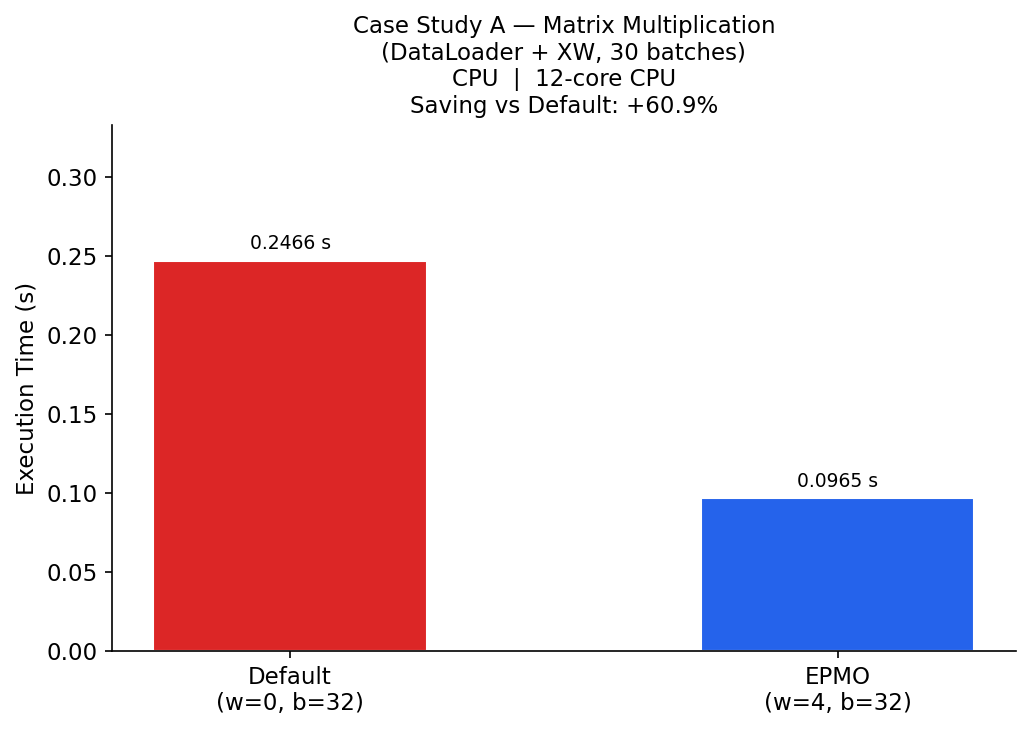

  Saved: case_A_matmul.png


In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
make_bar_chart(
    ax, t_default_A, t_epmo_A,
    title='Case Study A — Matrix Multiplication\n(DataLoader + XW, 30 batches)',
    env_label=env_label
)
plt.tight_layout()
plt.savefig('case_A_matmul.png', bbox_inches='tight')
plt.show()
print('  Saved: case_A_matmul.png')


---
## Case Study B — CNN Forward Pass

**What it tests:** How EPMO's config affects throughput when the compute is a
convolutional neural network forward pass — directly representative of CIFAR-10 training.

**Setup:**
- A small CNN: Conv(3→32, 3×3) → ReLU → Conv(32→64, 3×3) → ReLU → AdaptiveAvgPool → Linear(64→10)
- CIFAR-10 images (3×32×32) are passed through this network per batch
- We measure total time for 30 batches: DataLoader fetch + CNN forward pass
- No backward pass (pure inference) — isolates the data pipeline bottleneck

**Why this validates EPMO:** CNNs are memory-bandwidth sensitive.
Batch size and worker count directly control how saturated the data pipeline is.
EPMO finds the configuration where the pipeline never starves the compute.

In [16]:
print('='*55)
print('CASE STUDY B — CNN Forward Pass')
print('='*55)

class SmallCNN(nn.Module):
    """Lightweight CNN representative of CIFAR-10 classification."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(4),
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 10)
        )
    def forward(self, x):
        return self.net(x)

cnn_model = SmallCNN().to(DEVICE).eval()

def time_cnn_config(num_workers, batch_size, n_repeats=3):
    dataset = get_cifar10()
    times = []
    for _ in range(n_repeats):
        loader = DataLoader(
            dataset, batch_size=batch_size, num_workers=num_workers,
            pin_memory=HAS_GPU,
            persistent_workers=(num_workers > 0),
            prefetch_factor=2 if num_workers > 0 else None,
        )
        # warmup
        for i, (imgs, _) in enumerate(loader):
            if i + 1 >= WARMUP_BATCHES: break
            imgs = imgs.to(DEVICE)
            with torch.no_grad(): _ = cnn_model(imgs)
        if HAS_GPU: torch.cuda.synchronize()
        # measure
        start = time.perf_counter()
        for i, (imgs, _) in enumerate(loader):
            if i + 1 >= MEASURE_BATCHES: break
            imgs = imgs.to(DEVICE)
            with torch.no_grad(): _ = cnn_model(imgs)
        if HAS_GPU: torch.cuda.synchronize()
        times.append(time.perf_counter() - start)
        del loader
    return float(np.median(times))

print(f'  Running Default config (workers={default_w}, batch={default_b}) ...')
t_default_B = time_cnn_config(default_w, default_b)
print(f'  Default time: {t_default_B:.4f}s')

print(f'  Running EPMO config (workers={epmo_w}, batch={epmo_b}) ...')
t_epmo_B = time_cnn_config(epmo_w, epmo_b)
print(f'  EPMO time   : {t_epmo_B:.4f}s')

saving_B = (t_default_B - t_epmo_B) / t_default_B * 100
print(f'  Saving      : {saving_B:+.1f}%')


CASE STUDY B — CNN Forward Pass
  Running Default config (workers=0, batch=32) ...
  Default time: 0.5584s
  Running EPMO config (workers=4, batch=32) ...
  EPMO time   : 0.4430s
  Saving      : +20.7%


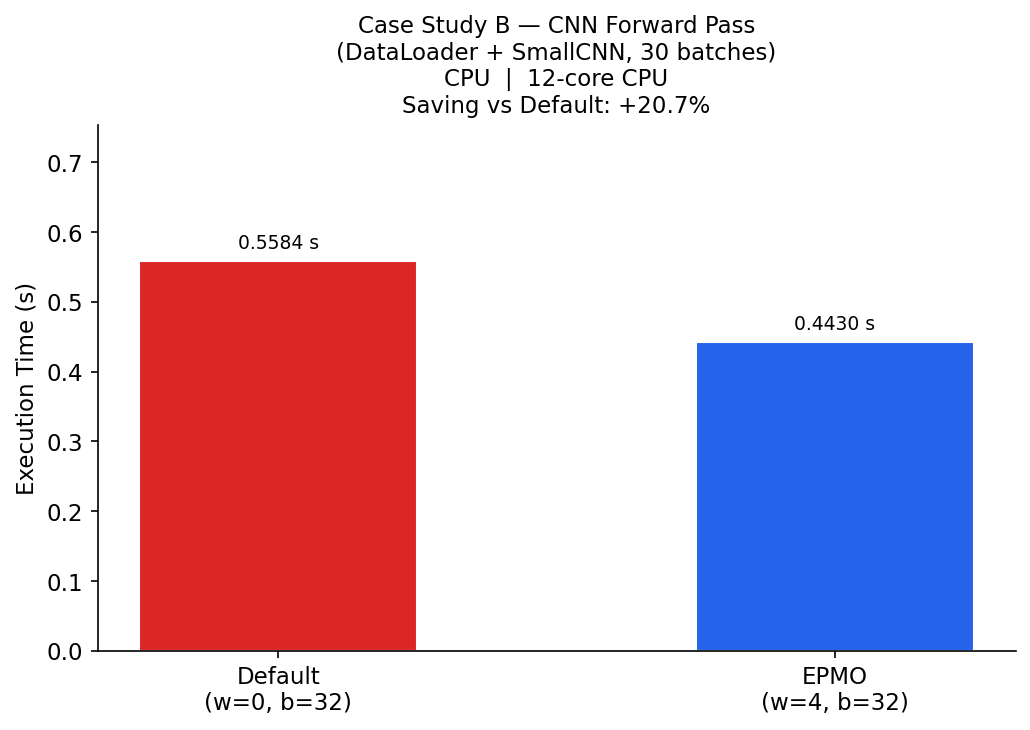

  Saved: case_B_cnn.png


In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
make_bar_chart(
    ax, t_default_B, t_epmo_B,
    title='Case Study B — CNN Forward Pass\n(DataLoader + SmallCNN, 30 batches)',
    env_label=env_label
)
plt.tight_layout()
plt.savefig('case_B_cnn.png', bbox_inches='tight')
plt.show()
print('  Saved: case_B_cnn.png')


---
## Case Study C — Transformer Attention

**What it tests:** How EPMO's config affects throughput when the compute is a
scaled dot-product attention block — the fundamental operation in Transformers.

**Setup:**
- Each CIFAR-10 batch is treated as a sequence of patches:
  image (3×32×32) is divided into 64 non-overlapping 4×4 patches → sequence length = 64
- Each patch is linearly projected to `d_model=128`
- One multi-head self-attention block: 4 heads, d_model=128
- We measure total time for 30 batches: DataLoader fetch + patch projection + attention forward

**Why this validates EPMO:** Transformers are extremely sensitive to batch size — 
attention scales as O(n²) in sequence length, making memory bandwidth critical.
EPMO finds the batch/worker balance that keeps the pipeline full without OOM.

In [18]:
print('='*55)
print('CASE STUDY C — Transformer Attention')
print('='*55)

PATCH_SIZE = 4          # 4×4 pixel patches
N_PATCHES  = (32 // PATCH_SIZE) ** 2   # = 64 patches per image
D_MODEL    = 128
N_HEADS    = 4

class PatchTransformer(nn.Module):
    """
    Vision Transformer (ViT) style block.
    Splits each 32×32 image into 4×4 patches → sequence of 64 tokens → self-attention.
    """
    def __init__(self):
        super().__init__()
        patch_dim = 3 * PATCH_SIZE * PATCH_SIZE   # 3×4×4 = 48
        self.patch_proj = nn.Linear(patch_dim, D_MODEL)
        self.attn = nn.MultiheadAttention(
            embed_dim=D_MODEL, num_heads=N_HEADS,
            batch_first=True
        )
        self.cls_head = nn.Linear(D_MODEL, 10)

    def patchify(self, x):
        """x: (B, 3, 32, 32) → (B, 64, 48)"""
        B = x.size(0)
        # unfold into patches
        x = x.unfold(2, PATCH_SIZE, PATCH_SIZE).unfold(3, PATCH_SIZE, PATCH_SIZE)
        # (B, 3, n_h, n_w, 4, 4)
        x = x.contiguous().view(B, 3, -1, PATCH_SIZE * PATCH_SIZE)
        # (B, 3, n_patches, 16) → (B, n_patches, 3*16)
        x = x.permute(0, 2, 1, 3).contiguous().view(B, N_PATCHES, -1)
        return x

    def forward(self, x):
        patches = self.patchify(x)          # (B, 64, 48)
        tokens  = self.patch_proj(patches)  # (B, 64, 128)
        out, _  = self.attn(tokens, tokens, tokens)  # self-attention
        cls     = out.mean(dim=1)           # mean pool over tokens
        return self.cls_head(cls)           # (B, 10)

vit_model = PatchTransformer().to(DEVICE).eval()

def time_transformer_config(num_workers, batch_size, n_repeats=3):
    dataset = get_cifar10()
    times = []
    for _ in range(n_repeats):
        loader = DataLoader(
            dataset, batch_size=batch_size, num_workers=num_workers,
            pin_memory=HAS_GPU,
            persistent_workers=(num_workers > 0),
            prefetch_factor=2 if num_workers > 0 else None,
        )
        # warmup
        for i, (imgs, _) in enumerate(loader):
            if i + 1 >= WARMUP_BATCHES: break
            imgs = imgs.to(DEVICE)
            with torch.no_grad(): _ = vit_model(imgs)
        if HAS_GPU: torch.cuda.synchronize()
        # measure
        start = time.perf_counter()
        for i, (imgs, _) in enumerate(loader):
            if i + 1 >= MEASURE_BATCHES: break
            imgs = imgs.to(DEVICE)
            with torch.no_grad(): _ = vit_model(imgs)
        if HAS_GPU: torch.cuda.synchronize()
        times.append(time.perf_counter() - start)
        del loader
    return float(np.median(times))

print(f'  Running Default config (workers={default_w}, batch={default_b}) ...')
t_default_C = time_transformer_config(default_w, default_b)
print(f'  Default time: {t_default_C:.4f}s')

print(f'  Running EPMO config (workers={epmo_w}, batch={epmo_b}) ...')
t_epmo_C = time_transformer_config(epmo_w, epmo_b)
print(f'  EPMO time   : {t_epmo_C:.4f}s')

saving_C = (t_default_C - t_epmo_C) / t_default_C * 100
print(f'  Saving      : {saving_C:+.1f}%')


CASE STUDY C — Transformer Attention
  Running Default config (workers=0, batch=32) ...
  Default time: 0.3486s
  Running EPMO config (workers=4, batch=32) ...
  EPMO time   : 0.2637s
  Saving      : +24.4%


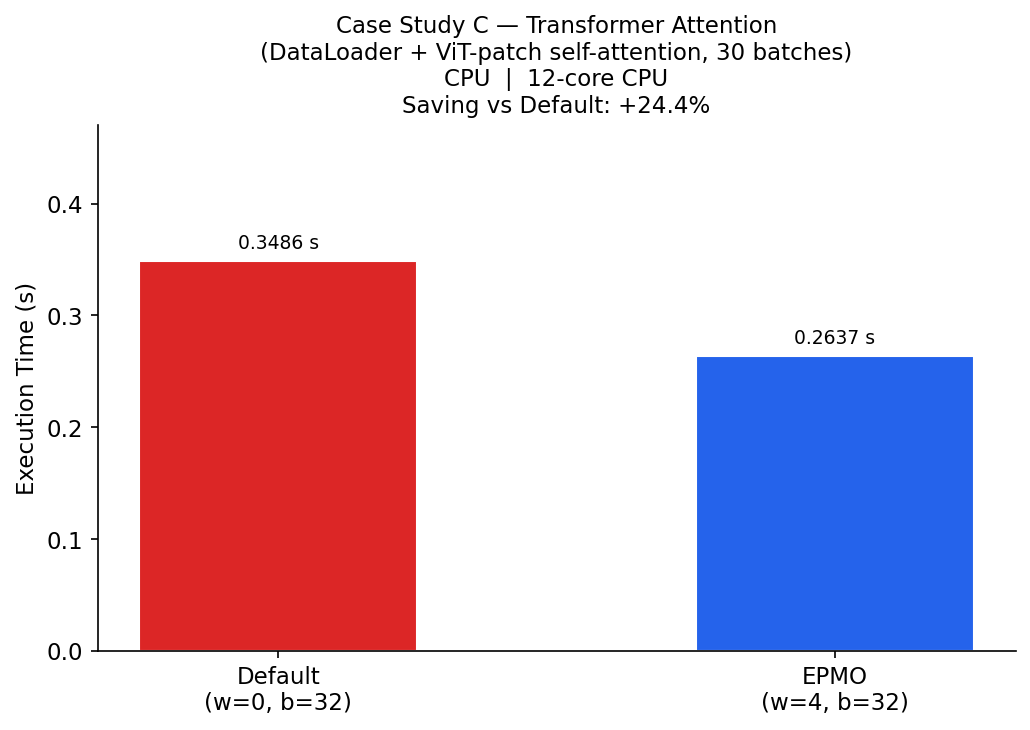

  Saved: case_C_transformer.png


In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
make_bar_chart(
    ax, t_default_C, t_epmo_C,
    title='Case Study C — Transformer Attention\n(DataLoader + ViT-patch self-attention, 30 batches)',
    env_label=env_label
)
plt.tight_layout()
plt.savefig('case_C_transformer.png', bbox_inches='tight')
plt.show()
print('  Saved: case_C_transformer.png')


---
## Summary — All Three Case Studies

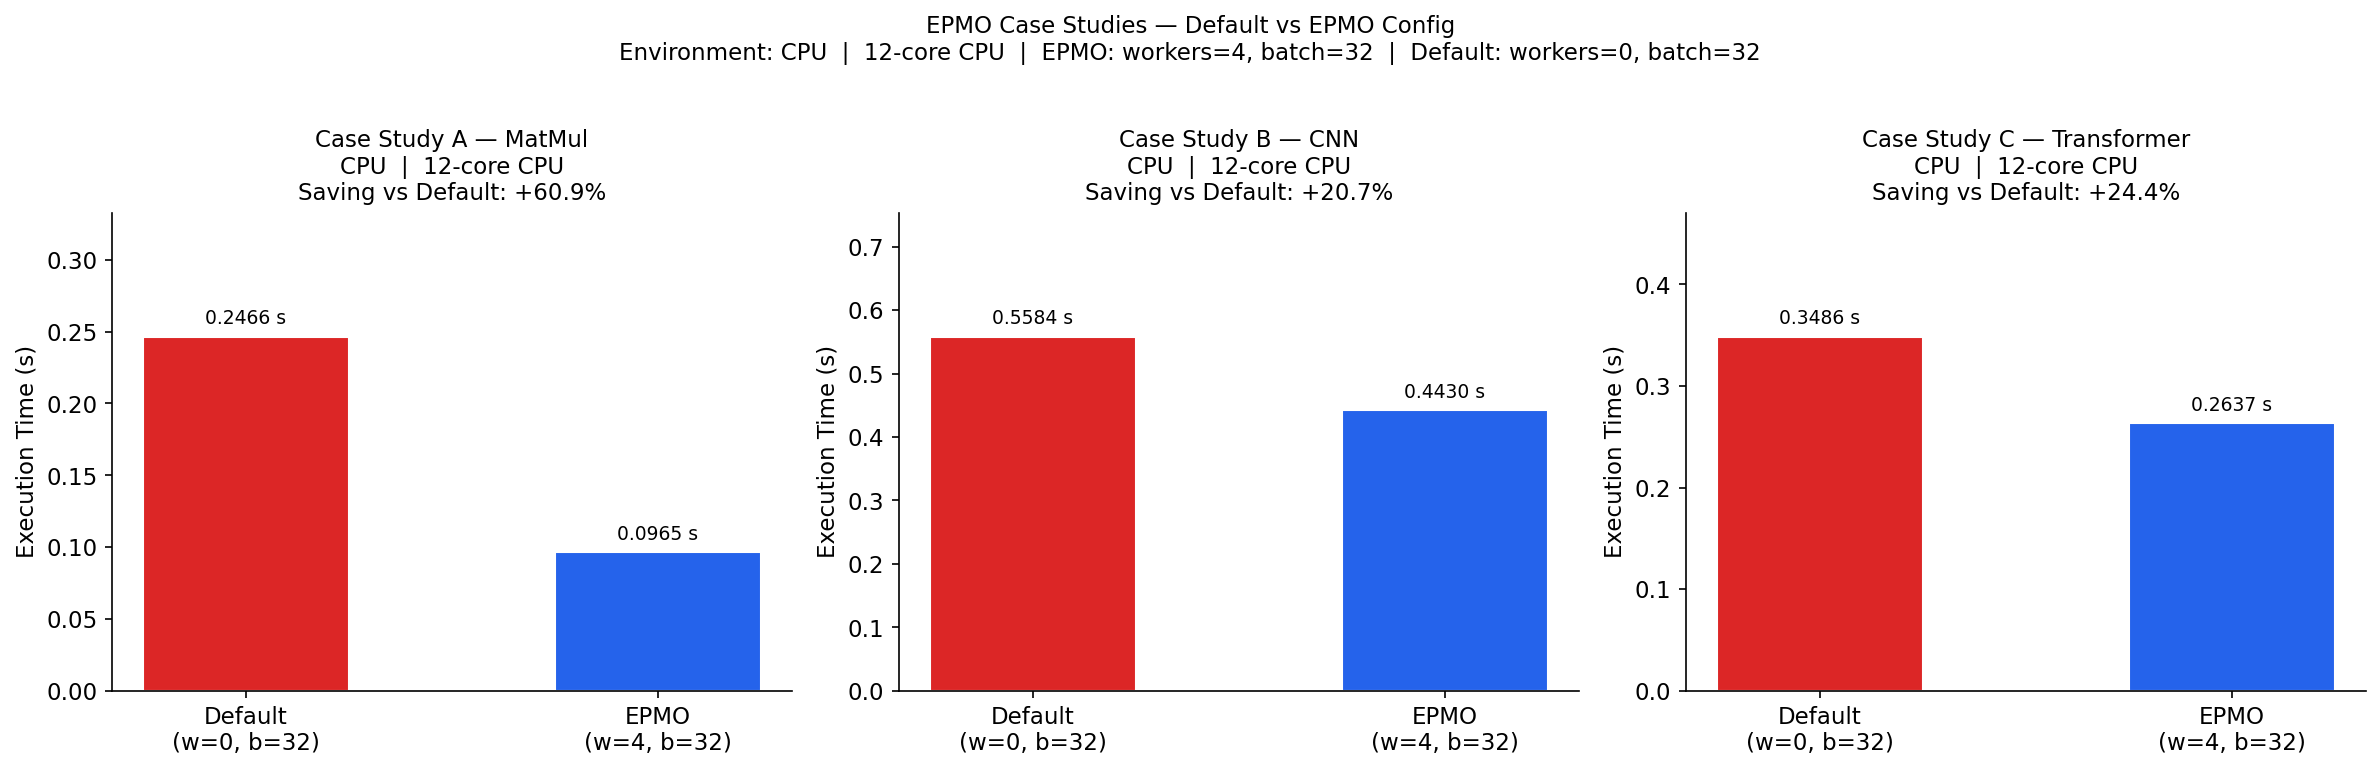

  Saved: epmo_casestudies_summary.png

CASE STUDY SUMMARY
  Environment : CPU  |  12-core CPU
  EPMO config : workers=4, batch_size=32
  Default     : workers=0, batch_size=32

  Case A — MatMul             Default=0.2466s  EPMO=0.0965s  Saving=+60.9%  [FASTER]
  Case B — CNN                Default=0.5584s  EPMO=0.4430s  Saving=+20.7%  [FASTER]
  Case C — Transformer        Default=0.3486s  EPMO=0.2637s  Saving=+24.4%  [FASTER]


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cases = [
    ('A — MatMul',      t_default_A, t_epmo_A),
    ('B — CNN',         t_default_B, t_epmo_B),
    ('C — Transformer', t_default_C, t_epmo_C),
]

for ax, (title, t_def, t_epmo) in zip(axes, cases):
    make_bar_chart(
        ax, t_def, t_epmo,
        title=f'Case Study {title}',
        env_label=env_label
    )

fig.suptitle(
    f'EPMO Case Studies — Default vs EPMO Config\n'
    f'Environment: {env_label}  |  '
    f'EPMO: workers={epmo_w}, batch={epmo_b}  |  '
    f'Default: workers={default_w}, batch={default_b}',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig('epmo_casestudies_summary.png', bbox_inches='tight')
plt.show()
print('  Saved: epmo_casestudies_summary.png')

print()
print('='*55)
print('CASE STUDY SUMMARY')
print('='*55)
print(f'  Environment : {env_label}')
print(f'  EPMO config : workers={epmo_w}, batch_size={epmo_b}')
print(f'  Default     : workers={default_w}, batch_size={default_b}')
print()
for title, t_def, t_epmo in cases:
    sav = (t_def - t_epmo) / t_def * 100
    verdict = 'FASTER' if sav > 0 else 'SLOWER (default wins here)'
    print(f'  Case {title:<22} Default={t_def:.4f}s  EPMO={t_epmo:.4f}s  '
          f'Saving={sav:+.1f}%  [{verdict}]')
print('='*55)
